# Experiment 1 — the mixture figure

Task document `__tasks/task_pnp_registration.tex`, Section 6.1. On the 1-D two-Gaussian prior, everything is exact: the prior $J$, the MMSE denoiser $\mathsf{D}$, and the recoverable regularizer $f_{\mathrm{reg}} = t\,J_{\mathrm{BVS}}$. Two networks are fitted to the same denoiser evaluations with the same loop (`src.gradfit.train_grad`): the semiconvex readout $J_\theta = G_\theta - \tfrac12\|y\|^2$, and a plain input-convex network as the control.

The outcome is guaranteed by theory (Propositions `prop:prox` and `prop:tight` of the task document); this run is an implementation test and produces the paper figure. Method and observations: `README.md`, `DESIGN.md`.

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())            # pnp_reg/, which holds pnpreg/

from pnpreg import experiment

# Full run: ~3 min on CPU (two fits at each sigma in (0.5, 0.25)).
results = experiment.run(smoke=False)

sigma=0.50  rel_l2 a/b = 0.012/1.010   min curv a/b/exact = -0.97/-0.00/-0.91   resid a/b = 0.002/0.998


sigma=0.25  rel_l2 a/b = 0.468/1.011   min curv a/b/exact = -0.85/-0.00/-0.95   resid a/b = 0.002/0.828


figure  -> /Users/gabrielpl/Claude/research/work_papers/dl_hj_eq/numerics/pnp_reg/results/figs/experiment1_mixture.png
metrics -> /Users/gabrielpl/Claude/research/work_papers/dl_hj_eq/numerics/pnp_reg/results/metrics.json


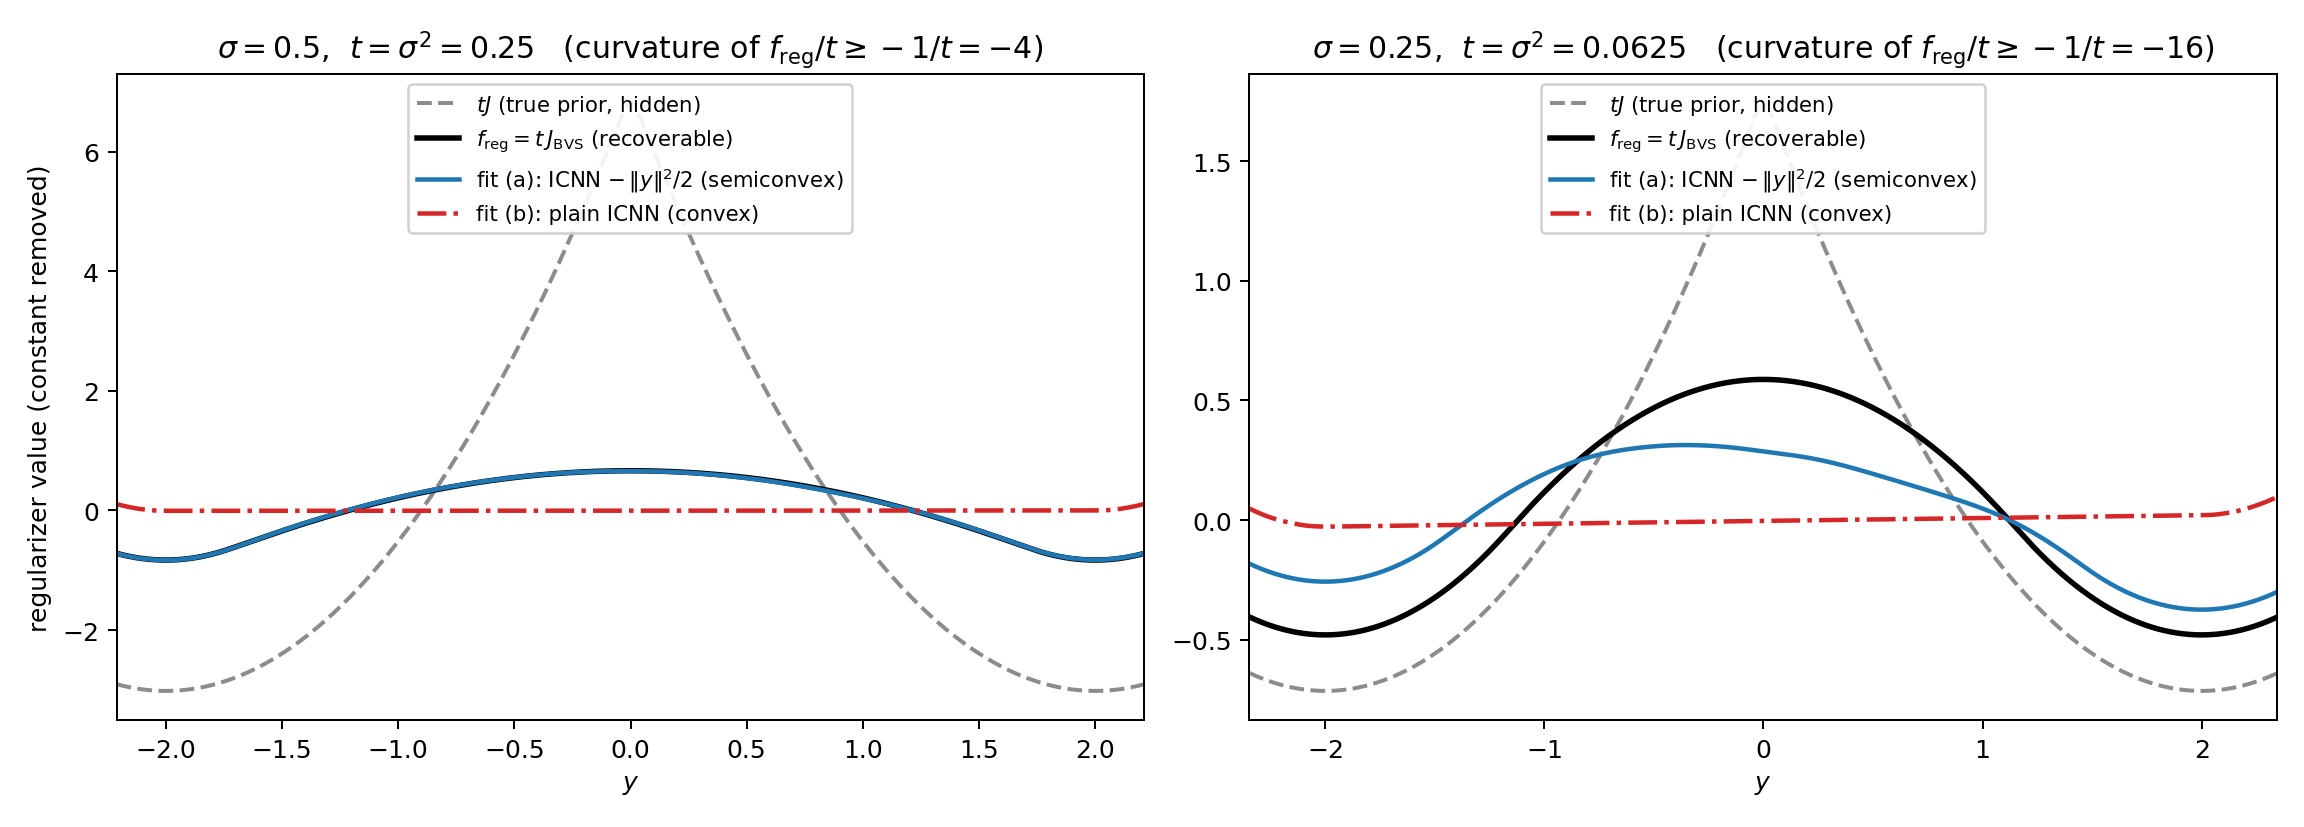

In [2]:
from IPython.display import Image, display
from pnpreg import paths
display(Image(filename=os.path.join(paths.FIGS, 'experiment1_mixture.png')))

In [3]:
import pandas as pd
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
pd.DataFrame(results)[['sigma', 't', 'rel_l2_a', 'rel_l2_b', 'resid_a', 'resid_b',
                       'min_curv_a', 'min_curv_b', 'min_curv_exact', 'window']]

,sigma,t,rel_l2_a,rel_l2_b,resid_a,resid_b,min_curv_a,min_curv_b,min_curv_exact,window
0,0.5,0.25,0.01152,1.01,0.00246,0.9978,-0.9651,-0.002384,-0.9113,"[-2.212136525754655, 2.210703270081631]"
1,0.25,0.0625,0.4684,1.011,0.001644,0.8279,-0.8525,-0.001192,-0.9505,"[-2.3464174959371245, 2.3440769992238866]"
